# NeuralQ S2SR — Crop Health Time Series at 1 m (ROI)

Super-resolve one agricultural ROI on a small time series, survey **all index timelines**, derive a **crop-health proxy**, **classify crop types from index dynamics**, and write an **ROI health report**.

**What this notebook does:**
1. Super-resolves the same ROI on 3–4 dates (`scripts/run_location.py`, 5-date MISR stack → `MS.tif` 1 m per date; skips LST by default).
2. Computes the full spectral-index set per date (`scripts/spectral_indices.py`: vegetation×6, water×4, burn×2, soil_urban×3).
3. Builds per-index timeline statistics (mean/median/p10–p90) on a center chip (1024 px) for speed.
4. Scores **crop-health proxy** from NDVI + NDRE + MTCI + NDMI − BSI/NDBI, maps health zones + stress change.
5. **Classifies crop types** from temporal index features (rule-based decision tree + optional KMeans cross-check).
6. Writes a reproducible **ROI health report**: `REPORT.md`, `timeseries.csv`, `health_map.tif`, `croptype.tif`, timeline PNGs.

**Science notes (read before agronomic use):**
- NDVI/GNDVI/EVI2/SAVI track greenness/cover; NDRE/MTCI track red-edge/chlorophyll; NDMI tracks canopy water; BSI/NDBI/NDTI track bare-soil exposure; NBR flags burn/stress. All are computed from `MS.tif` reflectance (DN/10000) at 1 m — no new satellite.
- Health here is a **spectral proxy**, not a diagnosis: clouds/shadows, soil background, variety, phenology stage, and irrigation all shift indices. No ground truth is used.
- Crop-type labels are **spectral-temporal archetypes** (e.g. strong green-up + senescence → cereal-like), not field-verified classes. Calibrate thresholds per region.

**Prereqs:** `conda activate neuralq-s2sr-core` (rasterio, numpy, matplotlib, torch). STAC + GPU needed for real SR; otherwise the notebook falls back to a documented synthetic MS cube so every cell still runs.

## 0. Setup — repo root, imports, environment

In [1]:
from pathlib import Path
import glob, json, os, sys
ROOT = Path.cwd()
for _up in [ROOT, *ROOT.parents]:  # walk up: works from notebooks/<track>/ too
    if (_up / 'scripts' / 'run_location.py').exists():
        ROOT = _up
        break
print('ROOT', ROOT)
sys.path.insert(0, str(ROOT / 'scripts'))
sys.path.insert(0, str(ROOT))
import numpy as np
import matplotlib
# inline backend: every figure renders INSIDE its cell output, no external viewer needed
%matplotlib inline
import matplotlib.pyplot as plt
import rasterio
from rasterio.windows import Window
print('numpy', np.__version__, '| rasterio', rasterio.__version__)
try:
    import torch
    print('torch', torch.__version__, 'cuda', torch.cuda.is_available())
except Exception as e:
    print('torch unavailable:', e)
try:
    import sklearn
    print('sklearn', sklearn.__version__)
    HAS_SKLEARN = True
except Exception:
    HAS_SKLEARN = False
    print('sklearn unavailable — KMeans cross-check will be skipped')

ROOT /home/khlaifiabilel/NeuralQ/neuralq-s2sr-core


numpy 2.5.2 | rasterio 1.5.0


torch 2.13.0+cu130 cuda True


sklearn 1.9.0


## 1. ROI + time-series config

Default ROI: **Sidi Bouzid plain, Tunisia** (cereals + vegetables + olive/fallow mosaic). Four dates span green-up → peak → senescence. Edit in place for your own ROI.

In [2]:
ROI = {'name': 'Sidi Bouzid plain, Tunisia', 'lon': 9.5600, 'lat': 35.0600}
DATES = ['2024-02-07','2024-03-15','2024-04-02','2024-04-20','2024-05-08','2024-05-25','2024-06-20','2024-07-15']
CHIP = 1024  # center-chip edge (px) used for stats/maps; full 4120 px is too heavy per cell
SKIP_LST = True  # keep time-series fast; LST needs AWS Requester-Pays
TS_DIR = ROOT / 'outputs' / 'TN' / 'crop-timeseries' / 'SidiBouzid-fields-2024'
TS_DIR.mkdir(parents=True, exist_ok=True)
print(ROI, DATES)
print('TS_DIR', TS_DIR)
BAND_ORDER = ('B02','B03','B04','B08','B05','B06','B07','B11','B12','B8A')
VEG = ['ndvi','gndvi','ndre','evi2','savi','mtci']
WATER = ['ndwi','mndwi','ndmi','awei']
SOIL = ['bsi','ndbi','ndti']
BURN = ['nbr','nbr2']
ALL_IDX = VEG + WATER + SOIL + BURN

{'name': 'Sidi Bouzid plain, Tunisia', 'lon': 9.56, 'lat': 35.06} ['2024-02-07', '2024-03-15', '2024-04-02', '2024-04-20', '2024-05-08', '2024-05-25', '2024-06-20', '2024-07-15']
TS_DIR /home/khlaifiabilel/NeuralQ/neuralq-s2sr-core/outputs/TN/crop-timeseries/SidiBouzid-fields-2024


## 2. Helpers — real SR runner, synthetic fallback, index + chip IO

In [3]:
import subprocess
def run_sr_for_date(lon, lat, date, out_dir: Path, skip_lst=True, timeout_s=3600):
    """Run scripts/run_location.py once; resumable (skip if MS.tif exists). Returns out_dir."""
    out_dir = Path(out_dir)
    ms = out_dir / 'MS.tif'
    if ms.exists():
        print(f'{date}: reuse {ms}')
        return out_dir
    cmd = [sys.executable, str(ROOT/'scripts'/'run_location.py'),
           '--lon', str(lon), '--lat', str(lat), '--date', date,
           '--tile-size', '412',  # single full-frame tile: no tiling seams (needs ~5GB VRAM)
           '--output', str(out_dir)]
    if skip_lst:
        cmd.append('--skip-lst')
    print('RUN:', ' '.join(cmd))
    r = subprocess.run(cmd, cwd=str(ROOT), timeout=timeout_s)
    if r.returncode != 0 or not ms.exists():
        raise RuntimeError(f'run_location failed for {date} (rc={r.returncode})')
    return out_dir

def synthetic_ms_for_date(out_dir: Path, date_idx: int, h: int = 512, w: int = 512):
    """Documented offline fallback: 3-field mosaic with known phenology.
    Field A (top): cereal-like green-up then senescence; B (middle): sustained vegetable;
    C (bottom): sparse/fallow. Returns MS.tif path."""
    from rasterio.crs import CRS
    from rasterio.transform import from_origin
    out_dir = Path(out_dir); out_dir.mkdir(parents=True, exist_ok=True)
    ms = out_dir / 'MS.tif'
    if ms.exists():
        return ms
    rng = np.random.default_rng(7)
    ndvi_curves = {'A': [0.30,0.35,0.55,0.65,0.70,0.72,0.55,0.38], 'B': [0.50,0.55,0.62,0.68,0.70,0.70,0.68,0.66], 'C': [0.22,0.25,0.30,0.32,0.31,0.30,0.29,0.28]}
    yy, xx = np.mgrid[0:h, 0:w]
    zone = np.where(yy < h//3, 0, np.where(yy < 2*h//3, 1, 2))
    curves = np.array([[ndvi_curves['A'][date_idx]],[ndvi_curves['B'][date_idx]],[ndvi_curves['C'][date_idx]]], dtype=np.float32)
    ndvi_t = curves[zone].reshape(h, w) + rng.normal(0, 0.03, (h,w)).astype(np.float32)
    ndvi_t = np.clip(ndvi_t, 0.05, 0.92)
    red = np.full((h,w), 0.09, np.float32) + rng.normal(0,0.008,(h,w)).astype(np.float32)
    nir = np.clip(red * (1+ndvi_t) / np.maximum(1-ndvi_t, 1e-3), 0.05, 0.65).astype(np.float32)
    refl = {}
    refl['B04'] = np.clip(red, 0.02, 0.4)
    refl['B08'] = nir
    refl['B03'] = np.clip(0.10 + 0.25*(nir-0.18), 0.03, 0.4).astype(np.float32)
    refl['B02'] = np.clip(0.08 + 0.10*(nir-0.18), 0.02, 0.3).astype(np.float32)
    refl['B05'] = np.clip(0.5*refl['B04']+0.5*nir*0.85, 0.03, 0.5).astype(np.float32)
    refl['B06'] = np.clip(nir*0.95, 0.03, 0.6).astype(np.float32)
    refl['B07'] = np.clip(nir*1.0, 0.03, 0.62).astype(np.float32)
    refl['B8A'] = np.clip(nir*0.97, 0.03, 0.6).astype(np.float32)
    refl['B11'] = np.clip(0.26 - 0.28*(ndvi_t-0.2), 0.05, 0.5).astype(np.float32)
    refl['B12'] = np.clip(0.23 - 0.24*(ndvi_t-0.2), 0.05, 0.45).astype(np.float32)
    prof = {'driver':'GTiff','height':h,'width':w,'count':10,'dtype':'uint16',
            'crs': CRS.from_epsg(32632),'transform': from_origin(500000, 3880000, 1, 1),
            'compress':'NONE','tiled':True,'blockxsize':256,'blockysize':256}
    stack = np.stack([(refl[b]*10000).round().astype(np.uint16) for b in BAND_ORDER])
    with rasterio.open(ms, 'w', **prof) as dst:
        dst.write(stack)
        dst.update_tags(field_model='A=cereal-like,B=vegetable-like,C=sparse-fallow', date_index=date_idx)
    print(f'synthetic {ms} ndvi~{float(np.mean(ndvi_t)):.3f}')
    return ms

def ensure_indices(ms_path: Path, indices_dir: Path):
    from spectral_indices import compute_indices
    need = [indices_dir/f'vegetation/{n}.tiff' for n in VEG]
    if all(p.exists() for p in need) and (indices_dir/'soil_urban'/'bsi.tiff').exists():
        return indices_dir
    compute_indices(Path(ms_path), Path(indices_dir), categories=['vegetation','water','soil_urban','burn'])
    return indices_dir

def read_chip(path: Path, chip: int = 1024):
    """Center-chip read (float32). Returns (array, profile, window_transform)."""
    path = Path(path)
    with rasterio.open(path) as src:
        h, w = src.height, src.width
        if min(h, w) <= chip:
            arr = src.read(1).astype(np.float32)
            return arr, src.profile.copy(), src.transform
        r0, c0 = (h-chip)//2, (w-chip)//2
        win = Window(c0, r0, chip, chip)
        arr = src.read(1, window=win).astype(np.float32)
        return arr, src.profile.copy(), src.window_transform(win)

def chip_stats(arr: np.ndarray):
    v = arr[np.isfinite(arr)]
    if v.size == 0:
        return {'mean': np.nan,'median': np.nan,'p10': np.nan,'p90': np.nan,'frac_valid': 0.0,'n': 0}
    return {'mean': float(np.mean(v)),'median': float(np.median(v)),
            'p10': float(np.percentile(v,10)),'p90': float(np.percentile(v,90)),
            'frac_valid': float(v.size/arr.size),'n': int(v.size)}

## 3. Build the SR time series (real run, synthetic fallback)

Each date yields `<TS_DIR>/<date>/MS.tif` + `indices/<category>/<name>.tiff`. Real inference needs STAC + GPU (~5–6 min/tile); on failure the notebook logs the error and uses the synthetic cube so analysis cells always run.

In [4]:
date_dirs, use_synthetic = {}, False
for i, date in enumerate(DATES):
    out = TS_DIR / date
    out.mkdir(parents=True, exist_ok=True)
    try:
        run_sr_for_date(ROI['lon'], ROI['lat'], date, out, skip_lst=SKIP_LST)
        date_dirs[date] = out
    except Exception as e:
        print(f'{date}: real SR unavailable ({type(e).__name__}: {e}) → synthetic fallback')
        use_synthetic = True
        ms = synthetic_ms_for_date(out, i)
        date_dirs[date] = out
for i, date in enumerate(DATES):
    ms = date_dirs[date] / 'MS.tif'
    if not ms.exists():
        synthetic_ms_for_date(date_dirs[date], i)
        use_synthetic = True
    ensure_indices(ms, date_dirs[date] / 'indices')
print('mode:', 'SYNTHETIC (offline demo)' if use_synthetic else 'REAL S2SR')
try:
    import rasterio as _rio
    for _d in DATES:
        with _rio.open(date_dirs[_d]/'MS.tif') as _s:
            if 'field_model' in (_s.tags() or {}):
                use_synthetic = True; break
    print('mode (tag-checked):', 'SYNTHETIC (offline demo)' if use_synthetic else 'REAL S2SR')
except Exception as _e:
    print('tag check skipped:', _e)
print('dates ready:', list(date_dirs))

2024-02-07: reuse /home/khlaifiabilel/NeuralQ/neuralq-s2sr-core/outputs/TN/crop-timeseries/SidiBouzid-fields-2024/2024-02-07/MS.tif
2024-03-15: reuse /home/khlaifiabilel/NeuralQ/neuralq-s2sr-core/outputs/TN/crop-timeseries/SidiBouzid-fields-2024/2024-03-15/MS.tif
2024-04-02: reuse /home/khlaifiabilel/NeuralQ/neuralq-s2sr-core/outputs/TN/crop-timeseries/SidiBouzid-fields-2024/2024-04-02/MS.tif
2024-04-20: reuse /home/khlaifiabilel/NeuralQ/neuralq-s2sr-core/outputs/TN/crop-timeseries/SidiBouzid-fields-2024/2024-04-20/MS.tif
2024-05-08: reuse /home/khlaifiabilel/NeuralQ/neuralq-s2sr-core/outputs/TN/crop-timeseries/SidiBouzid-fields-2024/2024-05-08/MS.tif
2024-05-25: reuse /home/khlaifiabilel/NeuralQ/neuralq-s2sr-core/outputs/TN/crop-timeseries/SidiBouzid-fields-2024/2024-05-25/MS.tif
2024-06-20: reuse /home/khlaifiabilel/NeuralQ/neuralq-s2sr-core/outputs/TN/crop-timeseries/SidiBouzid-fields-2024/2024-06-20/MS.tif
2024-07-15: reuse /home/khlaifiabilel/NeuralQ/neuralq-s2sr-core/outputs/TN/c

## 4. Index timelines — survey every index on the same chip

Mean/median/p10–p90 per date. Expect: vegetation indices rise to peak then fall for cereals; NDMI follows canopy water; BSI/NDBI mirror bare-soil exposure.

In [5]:
import csv
CAT_OF = {}
for _cat, _names in [('vegetation',VEG),('water',WATER),('soil_urban',SOIL),('burn',BURN)]:
    for _n in _names: CAT_OF[_n] = _cat
rows, cubes = [], {}
for date in DATES:
    cubes[date] = {}
    for name in ALL_IDX:
        p = date_dirs[date] / 'indices' / CAT_OF[name] / f'{name}.tiff'
        arr, prof, _ = read_chip(p, CHIP)
        cubes[date][name] = arr
        s = chip_stats(arr)
        rows.append({'date': date, 'index': name, 'category': CAT_OF[name], **s})
        if name in ('ndvi','ndre','mtci','ndmi','bsi'):
            print(f"{date} {name:6s} mean {s['mean']:+.3f} med {s['median']:+.3f} p10 {s['p10']:+.3f} p90 {s['p90']:+.3f} valid {s['frac_valid']:.2f}")
ts_csv = TS_DIR / 'timeseries.csv'
with open(ts_csv, 'w', newline='') as f:
    w = csv.DictWriter(f, fieldnames=list(rows[0].keys())); w.writeheader(); w.writerows(rows)
print('wrote', ts_csv, f'({len(rows)} rows)')

2024-02-07 ndvi   mean +0.273 med +0.225 p10 +0.138 p90 +0.460 valid 1.00
2024-02-07 ndre   mean +0.171 med +0.138 p10 +0.074 p90 +0.294 valid 1.00
2024-02-07 mtci   mean +1.174 med +1.079 p10 +0.500 p90 +1.831 valid 1.00
2024-02-07 ndmi   mean -0.035 med -0.062 p10 -0.124 p90 +0.074 valid 1.00
2024-02-07 bsi    mean +0.125 med +0.154 p10 +0.029 p90 +0.212 valid 1.00


/tmp/ipykernel_65808/229360155.py:79: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  arr = src.read(1, window=win).astype(np.float32)


2024-03-15 ndvi   mean +0.254 med +0.200 p10 +0.146 p90 +0.409 valid 1.00
2024-03-15 ndre   mean +0.158 med +0.118 p10 +0.078 p90 +0.267 valid 1.00
2024-03-15 mtci   mean +1.098 med +0.913 p10 +0.508 p90 +1.766 valid 1.00
2024-03-15 ndmi   mean -0.038 med -0.072 p10 -0.116 p90 +0.051 valid 1.00
2024-03-15 bsi    mean +0.124 med +0.159 p10 +0.048 p90 +0.196 valid 1.00


2024-04-02 ndvi   mean +0.233 med +0.187 p10 +0.143 p90 +0.344 valid 1.00
2024-04-02 ndre   mean +0.150 med +0.114 p10 +0.079 p90 +0.231 valid 1.00
2024-04-02 mtci   mean +1.035 med +0.814 p10 +0.482 p90 +1.637 valid 1.00
2024-04-02 ndmi   mean -0.052 med -0.083 p10 -0.117 p90 +0.006 valid 1.00
2024-04-02 bsi    mean +0.135 med +0.167 p10 +0.086 p90 +0.194 valid 1.00


2024-04-20 ndvi   mean +0.216 med +0.182 p10 +0.144 p90 +0.307 valid 1.00
2024-04-20 ndre   mean +0.133 med +0.106 p10 +0.078 p90 +0.201 valid 1.00
2024-04-20 mtci   mean +1.022 med +0.880 p10 +0.570 p90 +1.540 valid 1.00
2024-04-20 ndmi   mean -0.050 med -0.073 p10 -0.103 p90 +0.009 valid 1.00
2024-04-20 bsi    mean +0.136 med +0.159 p10 +0.085 p90 +0.184 valid 1.00


2024-05-08 ndvi   mean +0.170 med +0.149 p10 +0.122 p90 +0.241 valid 1.00
2024-05-08 ndre   mean +0.092 med +0.076 p10 +0.058 p90 +0.145 valid 1.00
2024-05-08 mtci   mean +0.636 med +0.555 p10 +0.315 p90 +1.073 valid 1.00
2024-05-08 ndmi   mean -0.080 med -0.089 p10 -0.117 p90 -0.038 valid 1.00
2024-05-08 bsi    mean +0.172 med +0.181 p10 +0.138 p90 +0.200 valid 1.00


2024-05-25 ndvi   mean +0.166 med +0.146 p10 +0.118 p90 +0.235 valid 1.00
2024-05-25 ndre   mean +0.095 med +0.081 p10 +0.059 p90 +0.147 valid 1.00
2024-05-25 mtci   mean +0.575 med +0.461 p10 +0.251 p90 +1.057 valid 1.00
2024-05-25 ndmi   mean -0.107 med -0.111 p10 -0.151 p90 -0.065 valid 1.00
2024-05-25 bsi    mean +0.183 med +0.189 p10 +0.148 p90 +0.215 valid 1.00


2024-06-20 ndvi   mean +0.150 med +0.134 p10 +0.108 p90 +0.208 valid 1.00
2024-06-20 ndre   mean +0.085 med +0.073 p10 +0.053 p90 +0.130 valid 1.00
2024-06-20 mtci   mean +0.498 med +0.395 p10 +0.192 p90 +0.945 valid 1.00
2024-06-20 ndmi   mean -0.121 med -0.124 p10 -0.158 p90 -0.085 valid 1.00
2024-06-20 bsi    mean +0.192 med +0.197 p10 +0.164 p90 +0.220 valid 1.00


2024-07-15 ndvi   mean +0.146 med +0.124 p10 +0.093 p90 +0.218 valid 1.00
2024-07-15 ndre   mean +0.073 med +0.056 p10 +0.035 p90 +0.128 valid 1.00
2024-07-15 mtci   mean +0.441 med +0.320 p10 +0.108 p90 +0.956 valid 1.00
2024-07-15 ndmi   mean -0.121 med -0.126 p10 -0.158 p90 -0.086 valid 1.00
2024-07-15 bsi    mean +0.204 med +0.210 p10 +0.177 p90 +0.234 valid 1.00


wrote /home/khlaifiabilel/NeuralQ/neuralq-s2sr-core/outputs/TN/crop-timeseries/SidiBouzid-fields-2024/timeseries.csv (120 rows)


## 5. Plot timelines (vegetation / water / soil)

wrote /home/khlaifiabilel/NeuralQ/neuralq-s2sr-core/outputs/TN/crop-timeseries/SidiBouzid-fields-2024/timelines.png


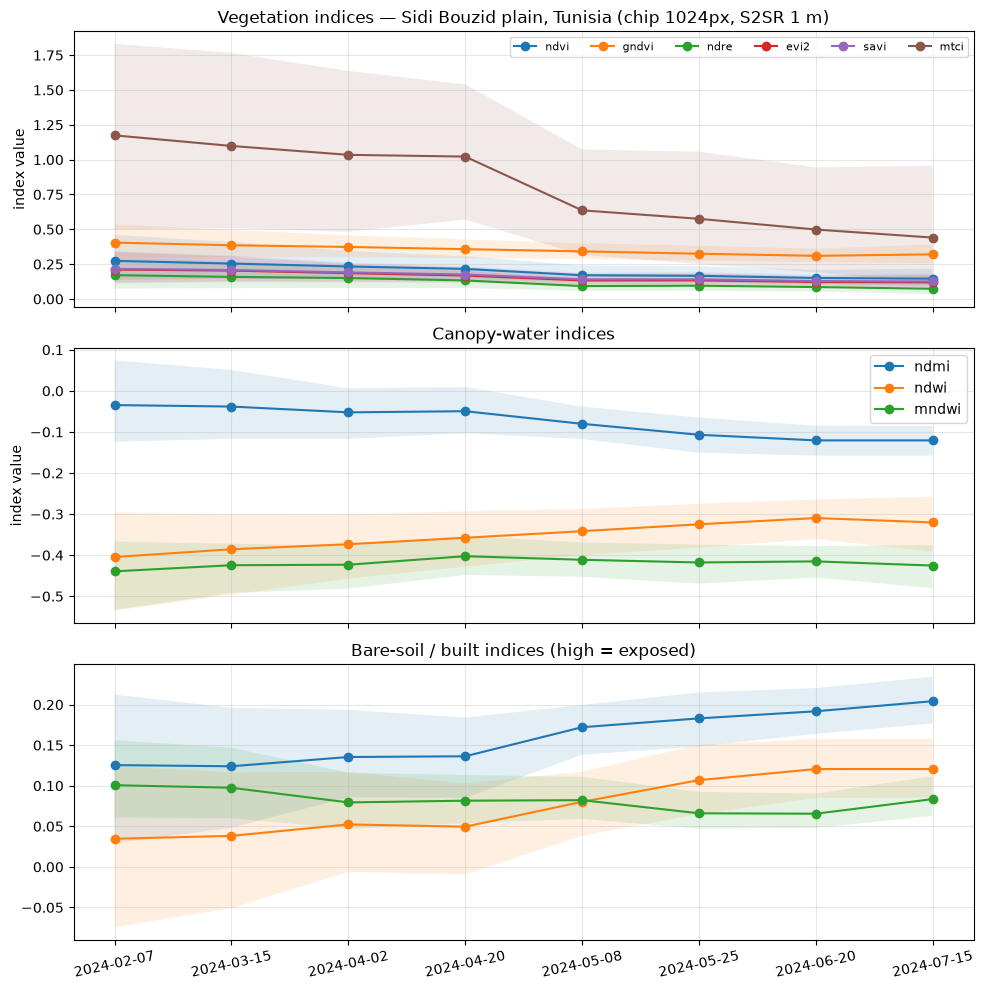

In [6]:
def _series(name, key='mean'):
    return [next(r[key] for r in rows if r['date']==d and r['index']==name) for d in DATES]
def _band(name, lo='p10', hi='p90'):
    return _series(name, lo), _series(name, hi)
x = np.arange(len(DATES))
fig, ax = plt.subplots(3, 1, figsize=(10, 10), sharex=True)
for name in VEG:
    y = _series(name); lo, hi = _band(name)
    ax[0].plot(x, y, marker='o', label=name); ax[0].fill_between(x, lo, hi, alpha=0.12)
ax[0].set_title(f"Vegetation indices — {ROI['name']} (chip {CHIP}px, {'synthetic' if use_synthetic else 'S2SR 1 m'})")
ax[0].set_ylabel('index value'); ax[0].legend(ncol=6, fontsize=8); ax[0].grid(alpha=0.3)
for name in ['ndmi','ndwi','mndwi']:
    y = _series(name); lo, hi = _band(name)
    ax[1].plot(x, y, marker='o', label=name); ax[1].fill_between(x, lo, hi, alpha=0.12)
ax[1].set_title('Canopy-water indices'); ax[1].set_ylabel('index value'); ax[1].legend(); ax[1].grid(alpha=0.3)
for name in SOIL:
    y = _series(name); lo, hi = _band(name)
    ax[2].plot(x, y, marker='o', label=name); ax[2].fill_between(x, lo, hi, alpha=0.12)
ax[2].set_title('Bare-soil / built indices (high = exposed)'); ax[2].set_xticks(x, DATES, rotation=12); ax[2].grid(alpha=0.3)
fig.tight_layout(); fig.savefig(TS_DIR/'timelines.png', dpi=130); print('wrote', TS_DIR/'timelines.png')
plt.show()  # render inline in the cell output


## 6. Crop-health proxy — score, zones, stress change

`health = 0.35·ndvi01 + 0.25·ndre01 + 0.15·mtci01 + 0.15·ndmi01 − 0.10·bsi01` (each 0–1 clipped; MTCI/6). Zones: water (MNDWI>0.25) → bare (NDVI<0.20 or BSI>0.12) → healthy ≥0.62 / moderate ≥0.50 / stressed ≥0.38 / poor <0.38. Stress change = NDVI(latest) − NDVI(earliest).

health zones (latest): {'bare/fallow': 0.978, 'stressed': 0.009, 'moderate': 0.013, 'healthy': 0.0}
mean health 0.351 | median 0.341
NDVI change 2024-02-07→2024-07-15: mean -0.127 (neg = senescence/stress, pos = green-up)


wrote /home/khlaifiabilel/NeuralQ/neuralq-s2sr-core/outputs/TN/crop-timeseries/SidiBouzid-fields-2024/health_maps.png


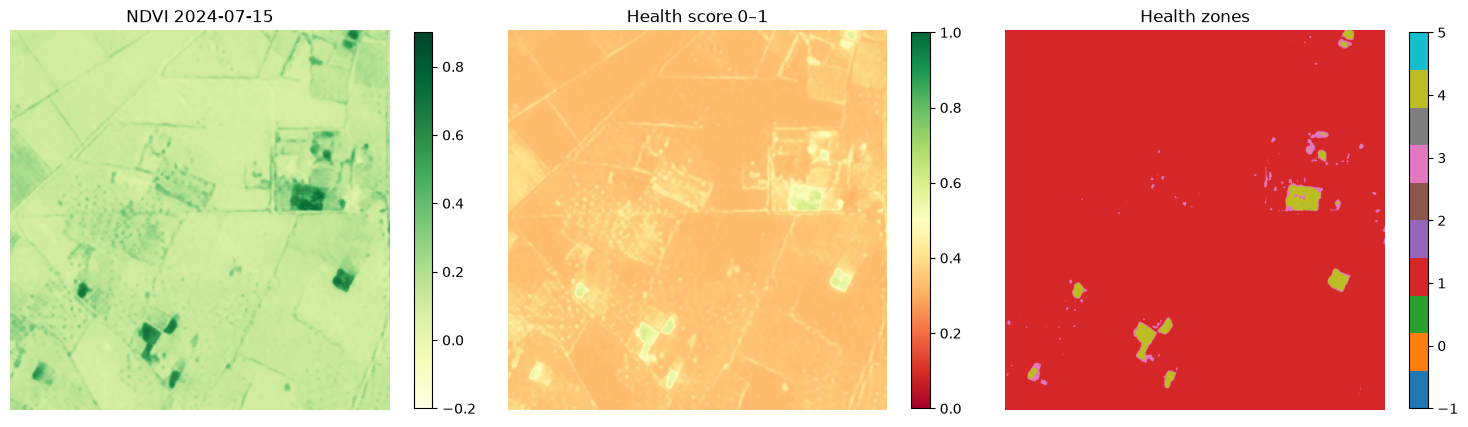

In [7]:
def _clip01(a): return np.clip(a, 0, 1)
latest, first = DATES[-1], DATES[0]
C = cubes[latest]; C0 = cubes[first]
ndvi01 = _clip01((C['ndvi']+1)/2); ndre01 = _clip01((C['ndre']+1)/2)
mtci01 = _clip01(C['mtci']/6.0); ndmi01 = _clip01((C['ndmi']+1)/2); bsi01 = _clip01((C['bsi']+1)/2)
health = (0.35*ndvi01 + 0.25*ndre01 + 0.15*mtci01 + 0.15*ndmi01 - 0.10*bsi01).astype(np.float32)
health[~np.isfinite(C['ndvi'])] = np.nan
is_water = C['mndwi'] > 0.25
is_bare = (~is_water) & ((C['ndvi'] < 0.20) | (C['bsi'] > 0.12))
zone = np.full(health.shape, 3, np.int8)  # default stressed
zone[health >= 0.62] = 5; zone[(health>=0.50)&(health<0.62)] = 4
zone[(health<0.50)&(health>=0.38)] = 3; zone[health<0.38] = 2
zone[is_bare] = 1; zone[is_water] = 0
zone[~np.isfinite(health) & ~is_water] = -1
NAMES = {-1:'nodata',0:'water',1:'bare/fallow',2:'poor',3:'stressed',4:'moderate',5:'healthy'}
vals, cnts = np.unique(zone[zone>=0], return_counts=True)
frac = {NAMES[int(v)]: float(c/(zone>=0).sum()) for v, c in zip(vals, cnts)}
print('health zones (latest):', {k: round(v,3) for k,v in frac.items()})
print(f"mean health {np.nanmean(health):.3f} | median {np.nanmedian(health):.3f}")
dndvi = (C['ndvi'] - C0['ndvi']).astype(np.float32)
print(f"NDVI change {first}→{latest}: mean {np.nanmean(dndvi):+.3f} (neg = senescence/stress, pos = green-up)")
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
im0 = ax[0].imshow(np.clip(C['ndvi'],-1,1), vmin=-0.2, vmax=0.9, cmap='YlGn'); ax[0].set_title(f'NDVI {latest}'); plt.colorbar(im0, ax=ax[0], shrink=0.8)
im1 = ax[1].imshow(np.clip(health,0,1), vmin=0, vmax=1, cmap='RdYlGn'); ax[1].set_title('Health score 0–1'); plt.colorbar(im1, ax=ax[1], shrink=0.8)
im2 = ax[2].imshow(zone, vmin=-1, vmax=5, cmap='tab10'); ax[2].set_title('Health zones'); plt.colorbar(im2, ax=ax[2], shrink=0.8)
for a in ax: a.axis('off')
fig.tight_layout(); fig.savefig(TS_DIR/'health_maps.png', dpi=130); print('wrote', TS_DIR/'health_maps.png')
plt.show()  # render inline in the cell output


## 7. Crop-type classification from index dynamics

Per-pixel temporal features (NDVI mean/max/amplitude/late-slope, MTCI/NDRE/NDMI/BSI means) feed an interpretable rule tree. A KMeans fit on the same standardized features is shown only as a consistency cross-check. Labels are archetypes — calibrate with field data before operational use.

crop-type fractions: {'fallow/bare': 0.798, 'vegetable/high-chl': 0.006, 'cereal-like': 0.003, 'mixed/other': 0.118, 'orchard/sparse': 0.075}


KMeans ok; NDVI-ordered cluster sizes: [640836, 278516, 58668, 9942, 60614]
wrote /home/khlaifiabilel/NeuralQ/neuralq-s2sr-core/outputs/TN/crop-timeseries/SidiBouzid-fields-2024/croptype.png


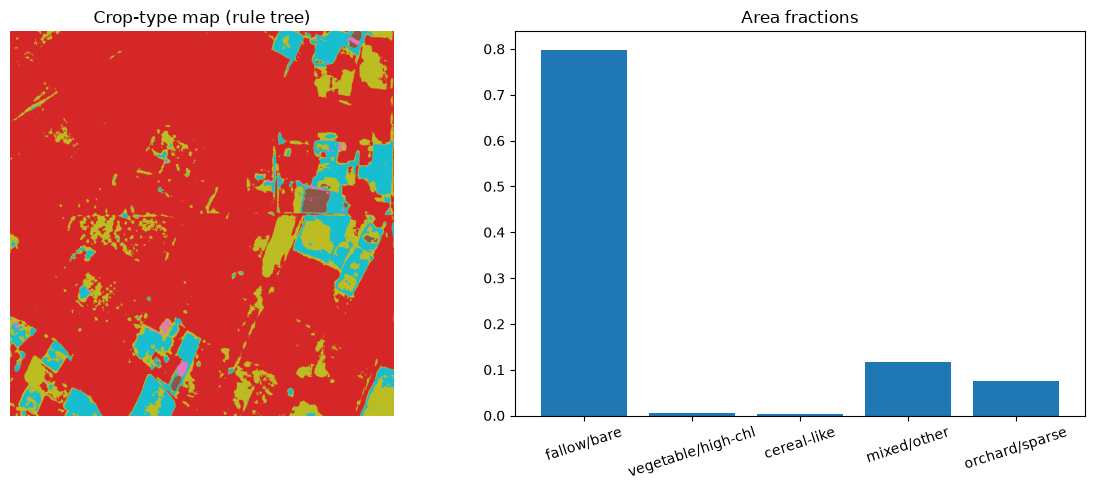

In [8]:
stack_ndvi = np.stack([cubes[d]['ndvi'] for d in DATES]).astype(np.float32)
ndvi_mean = np.nanmean(stack_ndvi, axis=0); ndvi_max = np.nanmax(stack_ndvi, axis=0)
ndvi_min = np.nanmin(stack_ndvi, axis=0); ndvi_amp = ndvi_max - ndvi_min
slope = (stack_ndvi[-1] - stack_ndvi[-2])  # late-season slope: neg = senescence
mtci_m = np.nanmean(np.stack([cubes[d]['mtci'] for d in DATES]), axis=0)
ndre_m = np.nanmean(np.stack([cubes[d]['ndre'] for d in DATES]), axis=0)
ndmi_m = np.nanmean(np.stack([cubes[d]['ndmi'] for d in DATES]), axis=0)
bsi_m = np.nanmean(np.stack([cubes[d]['bsi'] for d in DATES]), axis=0)
mndwi_m = np.nanmean(np.stack([cubes[d]['mndwi'] for d in DATES]), axis=0)
cls = np.full(ndvi_mean.shape, 4, np.int8)  # 4=mixed/other
cls[mndwi_m > 0.25] = 0                                   # 0 water
cls[(mndwi_m<=0.25)&(ndvi_max<0.35)&(bsi_m>0.02)] = 1      # 1 fallow/bare
cls[(mndwi_m<=0.25)&(ndvi_mean>0.55)&(mtci_m>1.8)] = 2     # 2 vegetable/high-chlorophyll
cls[(mndwi_m<=0.25)&(ndvi_amp>0.22)&(slope<-0.08)&(ndvi_mean<=0.62)] = 3  # 3 winter-cereal-like
cls[(mndwi_m<=0.25)&(ndvi_mean>=0.32)&(ndvi_mean<=0.52)&(bsi_m>-0.05)&(cls==4)] = 5  # 5 orchard/sparse
cls[~np.isfinite(ndvi_mean)] = -1
CNAMES = {-1:'nodata',0:'water',1:'fallow/bare',2:'vegetable/high-chl',3:'cereal-like',4:'mixed/other',5:'orchard/sparse'}
v2, c2 = np.unique(cls[cls>=0], return_counts=True)
cf = {CNAMES[int(v)]: float(c/(cls>=0).sum()) for v, c in zip(v2, c2)}
print('crop-type fractions:', {k: round(x,3) for k,x in cf.items()})
km_note = 'skipped (no sklearn)'
if HAS_SKLEARN:
    from sklearn.cluster import KMeans
    feats = np.stack([ndvi_mean, ndvi_amp, slope, np.clip(mtci_m,-2,6), ndre_m, ndmi_m, bsi_m], axis=-1)
    m = np.isfinite(feats).all(-1)
    Z = feats[m].reshape(-1, feats.shape[-1])
    Z = (Z - Z.mean(0)) / (Z.std(0) + 1e-6)
    km = KMeans(n_clusters=5, n_init=10, random_state=0).fit(Z)
    order = np.argsort([Z[km.labels_==k, 0].mean() for k in range(5)])
    km_note = f'KMeans ok; NDVI-ordered cluster sizes: {[int((km.labels_==k).sum()) for k in order]}'
    print(km_note)
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].imshow(cls, vmin=-1, vmax=5, cmap='tab10'); ax[0].set_title('Crop-type map (rule tree)'); ax[0].axis('off')
ax[1].bar(list(cf.keys()), list(cf.values())); ax[1].set_title('Area fractions'); ax[1].tick_params(axis='x', rotation=18)
fig.tight_layout(); fig.savefig(TS_DIR/'croptype.png', dpi=130); print('wrote', TS_DIR/'croptype.png')
plt.show()  # render inline in the cell output


## 8. ROI health report — export maps + markdown + CSV

In [9]:
def _save_like(ref_index_path: Path, array: np.ndarray, out_path: Path, dtype: str, nodata):
    import rasterio
    from rasterio.windows import Window
    ref_index_path = Path(ref_index_path); out_path = Path(out_path)
    with rasterio.open(ref_index_path) as src:
        h, w = src.height, src.width
        if min(h, w) <= array.shape[0]:
            prof, tr = src.profile.copy(), src.transform
        else:
            r0, c0 = (h-array.shape[0])//2, (w-array.shape[1])//2
            tr = src.window_transform(Window(c0, r0, array.shape[1], array.shape[0]))
            prof = src.profile.copy(); prof.update(height=array.shape[0], width=array.shape[1], transform=tr)
        prof.update(count=1, dtype=dtype, nodata=nodata, compress='NONE')
        for k in ('blockxsize','blockysize','tiled','compress'): prof.pop(k, None)
        with rasterio.open(out_path, 'w', **prof) as dst:
            dst.write(array.astype(dtype), 1)
    return out_path
ref_ndvi = date_dirs[latest] / 'indices' / 'vegetation' / 'ndvi.tiff'
health_u8 = np.where(np.isfinite(health), np.clip(health*100, 0, 100), 255).astype(np.uint8)
_save_like(ref_ndvi, health_u8, TS_DIR/'health_map.tif', 'uint8', 255)
_save_like(ref_ndvi, np.where(cls<0, 255, cls.astype(np.int16)).astype(np.uint8), TS_DIR/'croptype.tif', 'uint8', 255)
lines = []
lines += [f'# ROI Health Report — {ROI["name"]}', '', f'Dates: {" → ".join(DATES)}',
          f"Center: {ROI['lat']:.4f}N {ROI['lon']:.4f}E | mode: {'SYNTHETIC demo' if use_synthetic else 'REAL S2SR 1 m'} | chip: {CHIP}px center",
          '', '## Timeline (chip mean)', '']
for nm in ['ndvi','ndre','mtci','evi2','ndmi','bsi','ndbi']:
    lines.append(f"- {nm}: " + ' → '.join(f'{v:+.3f}' for v in _series(nm)))
lines += ['', '## Health zones @ latest (% area)', '']
for k, v in sorted(frac.items(), key=lambda kv: -kv[1]): lines.append(f'- {k}: {100*v:.1f}%')
lines += ['', '## Crop-type archetypes (% area)', '']
for k, v in sorted(cf.items(), key=lambda kv: -kv[1]): lines.append(f'- {k}: {100*v:.1f}%')
lines += ['', '## Interpretation (proxy, field-check required)',
  f"- Mean health {np.nanmean(health):.2f}; NDVI change {np.nanmean(dndvi):+.3f} ({first}→{latest}).",
  '- Green-up + late senescence + moderate MTCI → cereal-like; sustained high NDVI/MTCI → vegetable-like; low NDVI + high BSI → fallow/bare.',
  '- Negative NDMI drift + rising BSI ⇒ water-short / exposed soil; confirm with irrigation logs + rainfall.',
  '- Water mask from MNDWI>0.25; burn indices (NBR) near 0 ⇒ no fire signal in this window.', '',
  '## Methods & limits',
  '- 5-date MISR S2SR → 1 m MS (DN/10000); indices per scripts/spectral_indices.py; stats on center chip.',
  '- Thresholds are regional defaults (Sidi Bouzid). Re-tune per crop calendar; KMeans note: ' + km_note + '.',
  '- Not a fertilizer/irrigation prescription. Validate with field scouting before action.', '',
  '## Files', '- timeseries.csv, timelines.png, health_maps.png, croptype.png, health_map.tif (0–100, 255=nodata), croptype.tif (codes: ' + str(CNAMES) + ')']
(TS_DIR/'REPORT.md').write_text('\n'.join(lines) + '\n')
print('\n'.join(lines[:28]))
print('...')
print('wrote', TS_DIR/'REPORT.md')

# ROI Health Report — Sidi Bouzid plain, Tunisia

Dates: 2024-02-07 → 2024-03-15 → 2024-04-02 → 2024-04-20 → 2024-05-08 → 2024-05-25 → 2024-06-20 → 2024-07-15
Center: 35.0600N 9.5600E | mode: REAL S2SR 1 m | chip: 1024px center

## Timeline (chip mean)

- ndvi: +0.273 → +0.254 → +0.233 → +0.216 → +0.170 → +0.166 → +0.150 → +0.146
- ndre: +0.171 → +0.158 → +0.150 → +0.133 → +0.092 → +0.095 → +0.085 → +0.073
- mtci: +1.174 → +1.098 → +1.035 → +1.022 → +0.636 → +0.575 → +0.498 → +0.441
- evi2: +0.211 → +0.204 → +0.185 → +0.168 → +0.133 → +0.134 → +0.122 → +0.119
- ndmi: -0.035 → -0.038 → -0.052 → -0.050 → -0.080 → -0.107 → -0.121 → -0.121
- bsi: +0.125 → +0.124 → +0.135 → +0.136 → +0.172 → +0.183 → +0.192 → +0.204
- ndbi: +0.035 → +0.038 → +0.052 → +0.050 → +0.080 → +0.107 → +0.121 → +0.121

## Health zones @ latest (% area)

- bare/fallow: 97.8%
- moderate: 1.3%
- stressed: 0.9%
- healthy: 0.0%

## Crop-type archetypes (% area)

- fallow/bare: 79.8%
- mixed/other: 11.8%
- orchard/sparse:

## 9. QA — inventory of the time-series products

In [10]:
from output_layout import product_inventory, format_inventory_record
paths = sorted(TS_DIR.glob('*.tif')) + sorted(TS_DIR.glob('*.png')) + [TS_DIR/'timeseries.csv', TS_DIR/'REPORT.md']
paths = [p for p in paths if p.exists()]
tifs = [p for p in paths if p.suffix == '.tif']
if tifs:
    for rec in product_inventory(tifs):
        print(format_inventory_record(rec))
print('total files:', len(paths))
print('TS_DIR', TS_DIR)

croptype.tif: 1024x1024, 1 bands uint8, 1 m, compression=NONE, 1,049,716 bytes, sha256=8326174bcadde22d7040f5a689efb9805070bd7df271d648a43efd4fa52c4f12
health_map.tif: 1024x1024, 1 bands uint8, 1 m, compression=NONE, 1,049,716 bytes, sha256=83d9a7f80d088b8effc84f2cb54b83c2488cc2ee1ede7e6a3ec3b60a383d8d86
total files: 7
TS_DIR /home/khlaifiabilel/NeuralQ/neuralq-s2sr-core/outputs/TN/crop-timeseries/SidiBouzid-fields-2024
